<a href="https://colab.research.google.com/github/3011stan/ann-exercises-ifes/blob/main/01_backpropagation_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementacao do Backpropagation em Python

Esta atividade implementa um Multi Layer Perceptron (MLP) com NumPy, treina o modelo usando backpropagation e compara o resultado com o `MLPClassifier` do Scikit-Learn.

O notebook segue a abordagem didatica dos notebooks da disciplina, especialmente o exemplo multiclasse com `make_blobs`, mas a classe foi reescrita para explicitar melhor as etapas e aceitar configuracao de camadas, neuronios e funcoes de ativacao.

## Bibliotecas

Usaremos NumPy para a implementacao do MLP, Scikit-Learn para gerar a base sintetica e para o modelo de comparacao, e Matplotlib/Seaborn para visualizacao dos resultados.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelBinarizer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Base de dados

A base foi gerada com `make_blobs`, como nos exemplos da disciplina. A configuracao usa 100 amostras, 4 classes, duas variaveis de entrada, `center_box=(0, 1)` e `cluster_std=0.1`. Essa escolha deixa a tarefa pequena, visual e adequada para estudar o mecanismo de backpropagation, sem transformar a atividade em um problema de engenharia de dados.

In [2]:
def make_multiclass_dataset(n=100, n_classes=4, random_state=RANDOM_STATE):
    X, y = make_blobs(
        n_samples=n,
        centers=n_classes,
        n_features=2,
        center_box=(0, 1),
        cluster_std=0.1,
        random_state=random_state,
    )
    return X, y


X, y = make_multiclass_dataset()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Formato de X:', X.shape)
print('Formato de y:', y.shape)
print('Classes:', np.unique(y))

Formato de X: (100, 2)
Formato de y: (100,)
Classes: [0 1 2 3]


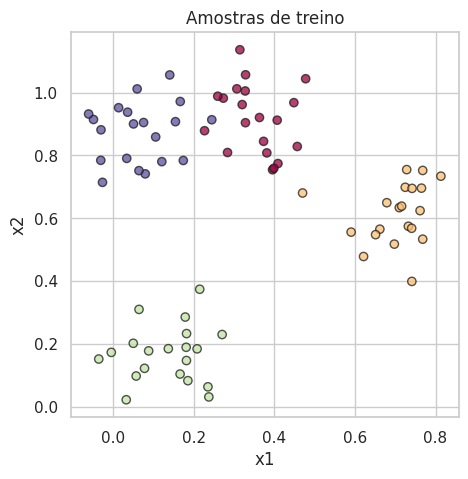

In [3]:
def plot_dataset(X, y, title='Dataset'):
    plt.figure(figsize=(5, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.75, cmap=plt.cm.Spectral, edgecolor='k')
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.show()


plot_dataset(X_train, y_train, 'Amostras de treino')

## Implementacao do MLP

A classe abaixo implementa as etapas principais do treinamento: inicializacao dos pesos, forward pass, calculo da perda, backpropagation e atualizacao por gradiente descendente. A estrutura das camadas fica em `n_hidden`, e a ativacao pode ser uma string unica ou uma lista de ativacoes. Quando uma unica string e informada, ela e usada em todas as camadas, incluindo a saida, de forma parecida com os exemplos da aula.

In [4]:
def include_bias(X):
    return np.hstack((np.ones((X.shape[0], 1)), X))


def activation_forward(z, name):
    if name == 'tanh':
        return np.tanh(z)
    if name == 'sigmoid':
        return 1 / (1 + np.exp(-z))
    if name == 'relu':
        return np.maximum(0, z)
    if name == 'linear':
        return z
    raise ValueError(f'Ativacao desconhecida: {name}')


def activation_derivative(z, activated, name):
    if name == 'tanh':
        return 1 - activated**2
    if name == 'sigmoid':
        return activated * (1 - activated)
    if name == 'relu':
        return (z > 0).astype(float)
    if name == 'linear':
        return np.ones_like(z)
    raise ValueError(f'Ativacao desconhecida: {name}')


class MLPBackpropagation:
    def __init__(
        self,
        n_hidden=None,
        activations='tanh',
        max_iter=10000,
        learning_rate=0.001,
        random_state=None,
    ):
        self.n_hidden = [50] if n_hidden is None else list(n_hidden)
        self.activations = activations
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.random_state = random_state

    def _resolve_activations(self):
        total_layers = len(self.n_hidden) + 1
        if isinstance(self.activations, str):
            return [self.activations] * total_layers
        if len(self.activations) != total_layers:
            raise ValueError('A quantidade de ativacoes deve acompanhar as camadas escondidas e a camada de saida.')
        return list(self.activations)

    def _initialize_weights(self, n_inputs, n_outputs):
        rng = np.random.default_rng(self.random_state)
        layer_sizes = [n_inputs] + self.n_hidden + [n_outputs]
        self.weights_ = []
        for previous_size, current_size in zip(layer_sizes[:-1], layer_sizes[1:]):
            shape = (previous_size + 1, current_size)
            self.weights_.append(rng.uniform(-1, 1, shape))

    def forward(self, X):
        self.inputs_with_bias_ = []
        self.z_values_ = []
        self.activations_values_ = []

        current = X.copy()
        for index, W in enumerate(self.weights_):
            current_bias = include_bias(current)
            z = current_bias @ W
            activation_name = self.layer_activations_[index]
            current = activation_forward(z, activation_name)

            self.inputs_with_bias_.append(current_bias)
            self.z_values_.append(z)
            self.activations_values_.append(current)

        return current

    def loss(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def backward(self, y_true, y_pred):
        n_samples = y_true.shape[0]
        delta = 2 * (y_pred - y_true) / n_samples
        gradients = [None] * len(self.weights_)

        for index in range(len(self.weights_) - 1, -1, -1):
            activation_name = self.layer_activations_[index]
            delta = delta * activation_derivative(
                self.z_values_[index], self.activations_values_[index], activation_name
            )

            gradients[index] = self.inputs_with_bias_[index].T @ delta

            if index > 0:
                delta = delta @ self.weights_[index][1:].T

        for index, gradient in enumerate(gradients):
            self.weights_[index] -= self.learning_rate * gradient

    def fit(self, X, y):
        self.lb_ = LabelBinarizer()
        y_encoded = self.lb_.fit_transform(y)
        if y_encoded.ndim == 1:
            y_encoded = y_encoded.reshape(-1, 1)

        self.layer_activations_ = self._resolve_activations()
        self._initialize_weights(X.shape[1], y_encoded.shape[1])
        self.loss_history_ = []

        for _ in range(self.max_iter):
            y_pred = self.forward(X)
            self.loss_history_.append(self.loss(y_encoded, y_pred))
            self.backward(y_encoded, y_pred)
        return self

    def predict_proba(self, X):
        raw_scores = self.forward(X)
        shifted = raw_scores - raw_scores.max(axis=1, keepdims=True)
        exp_scores = np.exp(shifted)
        return exp_scores / exp_scores.sum(axis=1, keepdims=True)

    def predict(self, X):
        raw_scores = self.forward(X)
        labels = np.argmax(raw_scores, axis=1)
        return self.lb_.classes_[labels]

## Treinamento do MLP proprio

O primeiro experimento usa uma camada escondida com 50 neuronios, `tanh`, taxa de aprendizado `0.001` e `10000` iteracoes. Esta e a configuracao mais proxima do exemplo multiclasse visto na aula.

In [5]:
custom_mlp = MLPBackpropagation(
    n_hidden=[50],
    activations='tanh',
    learning_rate=0.001,
    max_iter=10000,
    random_state=RANDOM_STATE,
)
custom_mlp.fit(X_train, y_train)

y_pred_custom = custom_mlp.predict(X_test)
acc_custom = accuracy_score(y_test, y_pred_custom)

print(f'Acuracia do MLP proprio: {acc_custom:.3f}')
print(f'Perda inicial: {custom_mlp.loss_history_[0]:.4f}')
print(f'Perda final: {custom_mlp.loss_history_[-1]:.4f}')

Acuracia do MLP proprio: 0.950
Perda inicial: 0.8686
Perda final: 0.0654


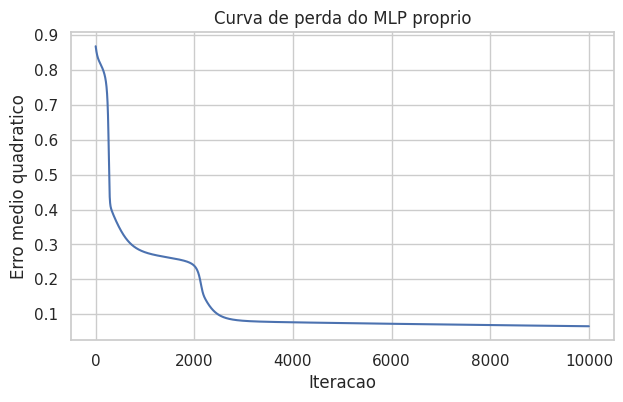

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(custom_mlp.loss_history_)
plt.title('Curva de perda do MLP proprio')
plt.xlabel('Iteracao')
plt.ylabel('Erro medio quadratico')
plt.show()

## Configuracao com mais camadas

Para mostrar que a implementacao aceita quantidade variavel de camadas, treinamos uma segunda rede com tres camadas escondidas de 10 neuronios. A ideia aqui nao e otimizar desempenho, mas demonstrar a configuracao pedida no enunciado.

In [7]:
custom_mlp_deep = MLPBackpropagation(
    n_hidden=[10, 10, 10],
    activations=['tanh', 'tanh', 'tanh', 'tanh'],
    learning_rate=0.001,
    max_iter=10000,
    random_state=RANDOM_STATE,
)
custom_mlp_deep.fit(X_train, y_train)
y_pred_deep = custom_mlp_deep.predict(X_test)
acc_deep = accuracy_score(y_test, y_pred_deep)

print(f'Acuracia com n_hidden=[10, 10, 10]: {acc_deep:.3f}')
print('Ativacoes configuradas:', custom_mlp_deep.layer_activations_)

Acuracia com n_hidden=[10, 10, 10]: 0.900
Ativacoes configuradas: ['tanh', 'tanh', 'tanh', 'tanh']


## Comparacao com Scikit-Learn

Agora treinamos um `MLPClassifier` com uma arquitetura equivalente ao experimento principal: uma camada escondida com 50 neuronios e ativacao `tanh`. A comparacao nao e perfeitamente identica, porque o Scikit-Learn tem varios detalhes internos de treinamento, mas serve como referencia consolidada.

In [8]:
sklearn_mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation='tanh',
    solver='sgd',
    learning_rate_init=0.001,
    max_iter=10000,
    random_state=RANDOM_STATE,
)
sklearn_mlp.fit(X_train, y_train)
y_pred_sklearn = sklearn_mlp.predict(X_test)
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)

print(f'Acuracia do MLP proprio: {acc_custom:.3f}')
print(f'Acuracia do Scikit-Learn: {acc_sklearn:.3f}')

Acuracia do MLP proprio: 0.950
Acuracia do Scikit-Learn: 0.950


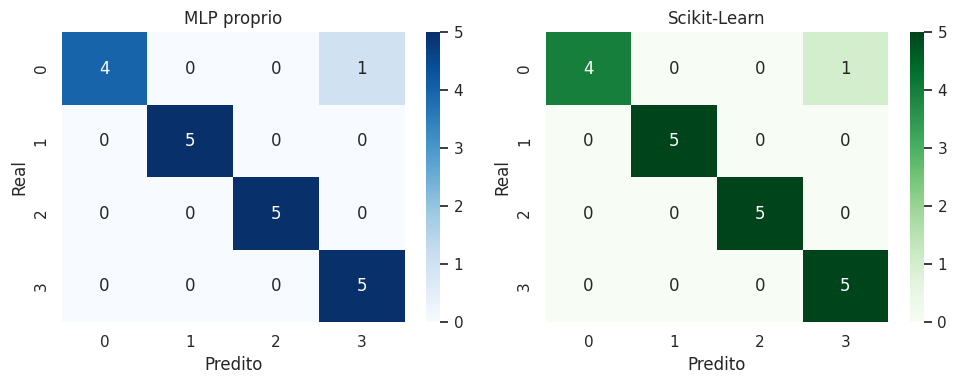

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_custom = confusion_matrix(y_test, y_pred_custom)
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)

sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('MLP proprio')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Scikit-Learn')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

## Regioes de decisao

Como a base tem apenas duas variaveis de entrada, podemos visualizar as regioes de decisao aprendidas pelos dois modelos.

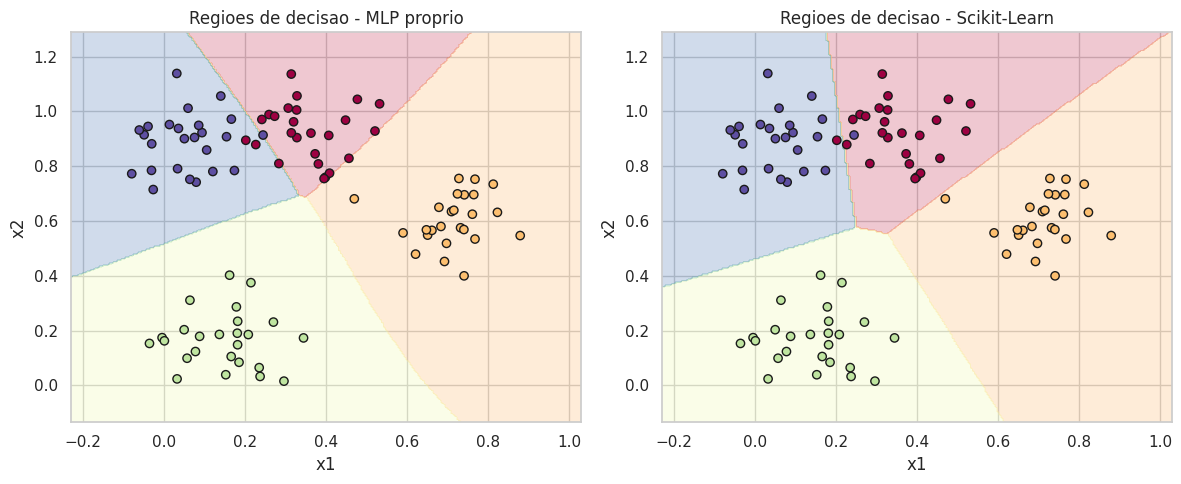

In [10]:
def plot_decision_regions(model, X, y, title):
    offset = 0.15
    x_min, x_max = X[:, 0].min() - offset, X[:, 0].max() + offset
    y_min, y_max = X[:, 1].min() - offset, X[:, 1].max() + offset
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, zz, alpha=0.25, cmap=plt.cm.Spectral)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral, edgecolor='k')
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_decision_regions(custom_mlp, X, y, 'Regioes de decisao - MLP proprio')
plt.subplot(1, 2, 2)
plot_decision_regions(sklearn_mlp, X, y, 'Regioes de decisao - Scikit-Learn')
plt.tight_layout()
plt.show()

## Conclusao

O MLP implementado com NumPy conseguiu aprender a separar as classes da base sintetica e produziu uma curva de perda decrescente, o que indica que o backpropagation esta ajustando os pesos na direcao esperada. A comparacao com o `MLPClassifier` mostra desempenho semelhante nesta base pequena.